In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    WhiteKernel, ConstantKernel, RBF, Matern,
    RationalQuadratic, ExpSineSquared, DotProduct
)

from tqdm import tqdm
# import multi regressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from src.feature_manager_sim import FeatureManagerSim
from src.feature_manager import FeatureManager
# from src.walk_forward_sim import WalkForwardSimulator

In [2]:
pd.read_parquet(f"../results/seven-day-ahead/samples/dgs_yields/2018-12-18.parquet")

,DGS1MO_future_val,DGS3MO_future_val,DGS6MO_future_val,DGS1_future_val,DGS2_future_val,DGS3_future_val,DGS5_future_val,DGS7_future_val,DGS10_future_val,DGS20_future_val,DGS30_future_val
0,2.191849,2.416619,2.493227,2.701473,2.700384,2.780108,2.782297,2.970278,2.940778,3.478094,3.663761
1,2.220607,2.314719,2.467360,2.739272,2.751357,2.828888,2.921853,2.973902,3.064227,3.502183,3.675246
2,2.277197,2.425882,2.495151,2.669300,2.756087,2.790299,2.855236,2.862579,2.940778,3.478094,3.646712
3,2.312379,2.325308,2.491933,2.666198,2.796915,2.754637,2.776603,2.851162,2.951118,3.595640,3.679479
4,2.277827,2.382559,2.576249,2.704074,2.762458,2.836102,2.725561,2.978585,2.986761,3.478094,3.703581
...,...,...,...,...,...,...,...,...,...,...,...
995,2.263055,2.387684,2.512825,2.700176,2.703996,2.724888,2.813014,2.940159,2.940778,3.478094,3.681020
996,2.268620,2.360327,2.569257,2.703212,2.840118,2.844880,2.811744,2.856800,2.940778,3.478094,3.646712
997,2.290958,2.312232,2.500789,2.658318,2.806581,2.794779,2.848115,2.805373,3.021990,3.539605,3.715188
998,2.145672,2.416682,2.499384,2.629818,2.716957,2.825287,2.822200,2.836395,2.940778,3.478094,3.702681


## Create Data For Modeling

In [3]:
# get the target, actual, and feature columns
feature_manager = FeatureManagerSim(features_config_path='../data/features_selected4.yaml')
feature_manager2 = FeatureManager(features_config_path='../data/features_selected3.yaml')
independent_variables = feature_manager2.get_features_for_time_pred(time_prediction='thirty-day-ahead')
dependent_variables = feature_manager.get_dependent_variables(time_prediction='thirty-day-ahead')
actuals_variables = feature_manager.get_actual_variables()

# print the outputs
print(f"Independent variables: {independent_variables}")
print(f"Dependent variables: {dependent_variables}")
print(f"Actual variables: {actuals_variables}")
# get the raw factor data
raw_ids = [x.split("_")[0] for x in independent_variables]
# check if the actuals and the raw_ids are in the data
# # load in the raw factor data
raw_data = pd.read_parquet('../data/fred_prorcessed_daily.parquet')
set(raw_ids + actuals_variables) - set(raw_data.columns.tolist())

INFO:src.feature_manager_sim:Loaded features for 6 future time predictions
INFO:src.feature_manager_sim:Available time predictions: ['seven-day-ahead', 'sixty-day-ahead', 'future_values', 'thirty-day-ahead', 'current_values', 'one-day-ahead']
INFO:src.feature_manager:Loaded features for 5 future time predictions
INFO:src.feature_manager:Available time predictions: ['seven-day-ahead', 'sixty-day-ahead', 'thirty-day-ahead', 'dependent_variables', 'one-day-ahead']
INFO:src.feature_manager:Retrieved 18 features for thirty-day-ahead
INFO:src.feature_manager_sim:Retrieved 11 dependent variables for thirty-day-ahead
INFO:src.feature_manager_sim:Retrieved 11 actual variables


Independent variables: ['U6RATE', 'MEDCPIM157SFRBCLE_moving_avg_60', 'STICKCPIM158SFRBATL_moving_avg_60', 'DGS5', 'DGS7', 'DGS10', 'DGS3', 'DGS3MO', 'DGS1', 'DGS30', 'REAINTRATREARAT1YE_moving_avg_60', 'DGS2', 'DGS6MO', 'REAINTRATREARAT1YE_exp_moving_avg_60', 'MEDCPIM157SFRBCLE_exp_moving_avg_60', 'U6RATE_exp_moving_avg_60', 'DGS20', 'REAINTRATREARAT1YE_exp_moving_avg_30']
Dependent variables: ['DGS1MO_gain_loss_30d', 'DGS3MO_gain_loss_30d', 'DGS6MO_gain_loss_30d', 'DGS1_gain_loss_30d', 'DGS2_gain_loss_30d', 'DGS3_gain_loss_30d', 'DGS5_gain_loss_30d', 'DGS7_gain_loss_30d', 'DGS10_gain_loss_30d', 'DGS20_gain_loss_30d', 'DGS30_gain_loss_30d']
Actual variables: ['DGS1MO', 'DGS3MO', 'DGS6MO', 'DGS1', 'DGS2', 'DGS3', 'DGS5', 'DGS7', 'DGS10', 'DGS20', 'DGS30']


set()

In [66]:
# create the dependent variable
for dep_var in actuals_variables:
        gain_loss_col = f'{dep_var}_gain_loss_7d'
        raw_data[gain_loss_col] = raw_data[dep_var].shift(-7) - raw_data[dep_var]

# create the moving average for the raw ids
raw_data['MEDCPIM157SFRBCLE_moving_avg_60'] = raw_data['MEDCPIM157SFRBCLE'].rolling(window=60).mean()
raw_data['STICKCPIM158SFRBATL_moving_avg_60'] = raw_data['STICKCPIM158SFRBATL'].rolling(window=60).mean()
raw_data['REAINTRATREARAT1YE_moving_avg_60'] = raw_data['REAINTRATREARAT1YE'].rolling(window=60).mean()
raw_data['REAINTRATREARAT1YE_exp_moving_avg_60'] = raw_data['REAINTRATREARAT1YE'].ewm(span=60, adjust=False).mean()
raw_data['MEDCPIM157SFRBCLE_exp_moving_avg_60'] = raw_data['MEDCPIM157SFRBCLE'].ewm(span=60, adjust=False).mean()
raw_data['U6RATE_exp_moving_avg_60'] = raw_data['U6RATE'].ewm(span=60, adjust=False).mean()

# ensure all the columns are available in the dataframe
full_columns = independent_variables + dependent_variables + actuals_variables
set(full_columns) - set(raw_data.columns.tolist())


set()

In [67]:
# persist the full data
full_columns = set(independent_variables).union(set(dependent_variables)).union(set(actuals_variables))
raw_data[list(full_columns)].to_parquet('src/data/bond_yields_train_shifted_7_sim2.parquet')

## GPR Analysis

In [74]:
# load in the data
seven_day_df = pd.read_parquet('../data/bond_yields_train_shifted_7_sim2.parquet')
# train_df = seven_day_df[(seven_day_df.index.to_timestamp() < pd.to_datetime('2018-01-01')) & (seven_day_df.index.to_timestamp() >= pd.to_datetime('2011-01-01'))]
#
# # print the min and max index values
# print(f"Min index value: {train_df.index.min()}")
# print(f"Max index value: {train_df.index.max()}")
# train_df.head()

In [78]:
# relabel actuals with a suffix _actuals
for actual_var in actuals_variables:
    seven_day_df[f"{actual_var}_actuals"] = seven_day_df[actual_var]

actuals_variables = [f"{x}_actuals" for x in actuals_variables]
seven_day_df[actuals_variables].head()

,DGS1MO_actuals,DGS3MO_actuals,DGS6MO_actuals,DGS1_actuals,DGS2_actuals,DGS3_actuals,DGS5_actuals,DGS7_actuals,DGS10_actuals,DGS20_actuals,DGS30_actuals
period,,,,,,,,,,,
1960-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1960-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1960-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1960-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1960-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [79]:
train_df = seven_day_df[(seven_day_df.index.to_timestamp() < pd.to_datetime('2018-01-01')) & (seven_day_df.index.to_timestamp() >= pd.to_datetime('2011-01-01'))]

# print the min and max index values
print(f"Min index value: {train_df.index.min()}")
print(f"Max index value: {train_df.index.max()}")
train_df.head()

Min index value: 2011-01-01
Max index value: 2017-12-31


,DGS7_gain_loss_7d,DGS2,DGS30,DGS10_gain_loss_7d,STICKCPIM158SFRBATL_moving_avg_60,DGS3_gain_loss_7d,MEDCPIM157SFRBCLE_exp_moving_avg_60,REAINTRATREARAT1YE_moving_avg_60,DGS6MO_gain_loss_7d,U6RATE_exp_moving_avg_60,...,DGS3MO_actuals,DGS6MO_actuals,DGS1_actuals,DGS2_actuals,DGS3_actuals,DGS5_actuals,DGS7_actuals,DGS10_actuals,DGS20_actuals,DGS30_actuals
period,,,,,,,,,,,,,,,,,,,,,
2011-01-01,-0.02,0.61,4.34,0.04,1.182332,0.00,0.113765,-1.046454,-0.01,16.655515,...,0.12,0.19,0.29,0.61,1.02,2.01,2.71,3.30,4.13,4.34
2011-01-02,-0.02,0.61,4.34,0.04,1.188687,0.00,0.116182,-1.045512,-0.01,16.637301,...,0.12,0.19,0.29,0.61,1.02,2.01,2.71,3.30,4.13,4.34
2011-01-03,-0.09,0.61,4.39,-0.04,1.195041,-0.04,0.118520,-1.044571,-0.01,16.619685,...,0.15,0.19,0.29,0.61,1.03,2.02,2.74,3.36,4.18,4.39
2011-01-04,-0.02,0.63,4.44,0.01,1.201396,-0.01,0.120781,-1.043629,0.00,16.602646,...,0.14,0.19,0.28,0.63,1.04,2.01,2.72,3.36,4.21,4.44
2011-01-05,-0.15,0.71,4.55,-0.10,1.207751,-0.13,0.122968,-1.042687,-0.01,16.586166,...,0.14,0.19,0.31,0.71,1.16,2.14,2.86,3.50,4.34,4.55


In [80]:
# use the first 2000 records as the analysis data
analysis_df = train_df.iloc[:1500]
# get the min and max index values
print(f"Min index value: {analysis_df.index.min()}")
print(f"Max index value: {analysis_df.index.max()}")

Min index value: 2011-01-01
Max index value: 2015-02-08


In [81]:
# scale the predictor variables in the analysis dataframe
scaler = StandardScaler()
analysis_df[independent_variables] = scaler.fit_transform(analysis_df[independent_variables])
analysis_df[independent_variables].describe()

/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_70499/2474242690.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  analysis_df[independent_variables] = scaler.fit_transform(analysis_df[independent_variables])


,U6RATE,MEDCPIM157SFRBCLE_moving_avg_60,STICKCPIM158SFRBATL_moving_avg_60,DGS5,DGS7,DGS10,DGS3,DGS3MO,DGS1,DGS30,REAINTRATREARAT1YE_moving_avg_60,DGS6MO,REAINTRATREARAT1YE_exp_moving_avg_60,MEDCPIM157SFRBCLE_exp_moving_avg_60,U6RATE_exp_moving_avg_60,DGS20,DGS1MO,DGS2
count,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03
mean,5.305386e-16,-8.337035e-16,3.789561e-17,3.221127e-16,-3.979039e-16,-5.021169e-16,-9.473903e-17,-1.894781e-16,-7.579123e-17,-7.579123e-17,4.168517e-16,-4.168517e-16,-2.273737e-16,-7.863340e-16,1.515825e-16,4.926430e-16,-2.652693e-16,7.579123e-17
std,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00
min,-2.056759e+00,-2.962346e+00,-3.214820e+00,-1.537072e+00,-1.688893e+00,-1.718607e+00,-1.309336e+00,-1.570287e+00,-1.483241e+00,-2.053729e+00,-2.193904e+00,-1.859981e+00,-2.314592e+00,-3.209525e+00,-1.989441e+00,-1.756842e+00,-1.146087e+00,-1.495149e+00
25%,-8.744619e-01,-6.722049e-01,-5.863764e-01,-9.568505e-01,-8.823600e-01,-8.081181e-01,-9.185887e-01,-7.286612e-01,-8.739123e-01,-7.245370e-01,-6.333969e-01,-8.614230e-01,-6.715296e-01,-6.443430e-01,-8.849885e-01,-7.438737e-01,-6.332966e-01,-7.400923e-01
50%,2.421519e-01,-1.127475e-01,-8.218632e-03,1.821037e-01,1.867656e-01,-1.206058e-01,-1.370932e-01,-1.675771e-01,-2.645839e-01,-2.602303e-01,-1.627471e-01,-1.125042e-01,-1.831131e-01,-9.856203e-02,1.913188e-01,-2.116360e-01,-3.769012e-01,-3.282435e-01
75%,7.019341e-01,5.744827e-01,5.710812e-01,8.053051e-01,7.307067e-01,6.783951e-01,8.575373e-01,6.740490e-01,5.478539e-01,5.727906e-01,5.316932e-01,8.860541e-01,4.764282e-01,5.621455e-01,7.757100e-01,5.953050e-01,3.922849e-01,4.954541e-01
max,1.555815e+00,2.456175e+00,2.702662e+00,2.417033e+00,2.456313e+00,2.592281e+00,2.704708e+00,2.918385e+00,3.188277e+00,2.516506e+00,2.739602e+00,2.383892e+00,3.824142e+00,2.751996e+00,1.677770e+00,2.569735e+00,7.058564e+00,3.378396e+00


In [82]:
for actual_var in actuals_variables:
    analysis_df[f"{actual_var}_forecasting"] = analysis_df[actual_var]

depenedent_vars2 = [f"{x}_forecasting" for x in actuals_variables]

for dependent_var in dependent_variables:
    analysis_df[f"{dependent_var}_normalized"] = analysis_df[dependent_var]

depenedent_vars3 = [f"{x}_normalized" for x in dependent_variables]
#
# scale the values
scaler2 = StandardScaler()
analysis_df[depenedent_vars2] = scaler2.fit_transform(analysis_df[depenedent_vars2])

scaler3 = StandardScaler()
analysis_df[depenedent_vars3] = scaler3.fit_transform(analysis_df[depenedent_vars3])
analysis_df[depenedent_vars3].describe()

/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_70499/2704171168.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  analysis_df[f"{actual_var}_forecasting"] = analysis_df[actual_var]
/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_70499/2704171168.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  analysis_df[f"{actual_var}_forecasting"] = analysis_df[actual_var]
/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_70499/2704171168.py:2: SettingWithCopyWarning: 
A value is tryi

,DGS1MO_gain_loss_7d_normalized,DGS3MO_gain_loss_7d_normalized,DGS6MO_gain_loss_7d_normalized,DGS1_gain_loss_7d_normalized,DGS2_gain_loss_7d_normalized,DGS3_gain_loss_7d_normalized,DGS5_gain_loss_7d_normalized,DGS7_gain_loss_7d_normalized,DGS10_gain_loss_7d_normalized,DGS20_gain_loss_7d_normalized,DGS30_gain_loss_7d_normalized
count,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03
mean,8.881784e-18,-2.368476e-17,-3.552714e-18,-3.315866e-17,-4.736952e-18,2.842171e-17,9.473903e-18,2.368476e-17,9.473903e-18,-4.736952e-18,-2.368476e-17
std,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00
min,-9.060366e+00,-5.899901e+00,-6.655578e+00,-5.144753e+00,-3.729913e+00,-3.430664e+00,-3.908128e+00,-4.171343e+00,-4.452838e+00,-4.773298e+00,-5.014106e+00
25%,-3.106683e-01,-5.586548e-01,-5.755737e-01,-5.020949e-01,-6.231480e-01,-5.478300e-01,-5.661114e-01,-6.637038e-01,-6.508728e-01,-6.170322e-01,-6.263903e-01
50%,1.339460e-02,3.481701e-02,3.242669e-02,1.375602e-02,-1.795020e-03,1.281260e-03,-7.463837e-02,-4.986694e-02,-1.203661e-01,-9.749906e-02,-9.986442e-02
75%,3.374575e-01,6.282888e-01,6.404271e-01,5.296069e-01,4.124403e-01,5.503925e-01,5.151292e-01,6.516609e-01,6.753940e-01,5.952118e-01,6.021701e-01
max,5.846526e+00,5.376063e+00,4.288430e+00,4.656414e+00,5.176147e+00,4.943283e+00,4.152029e+00,3.983918e+00,3.593181e+00,3.019700e+00,3.059291e+00


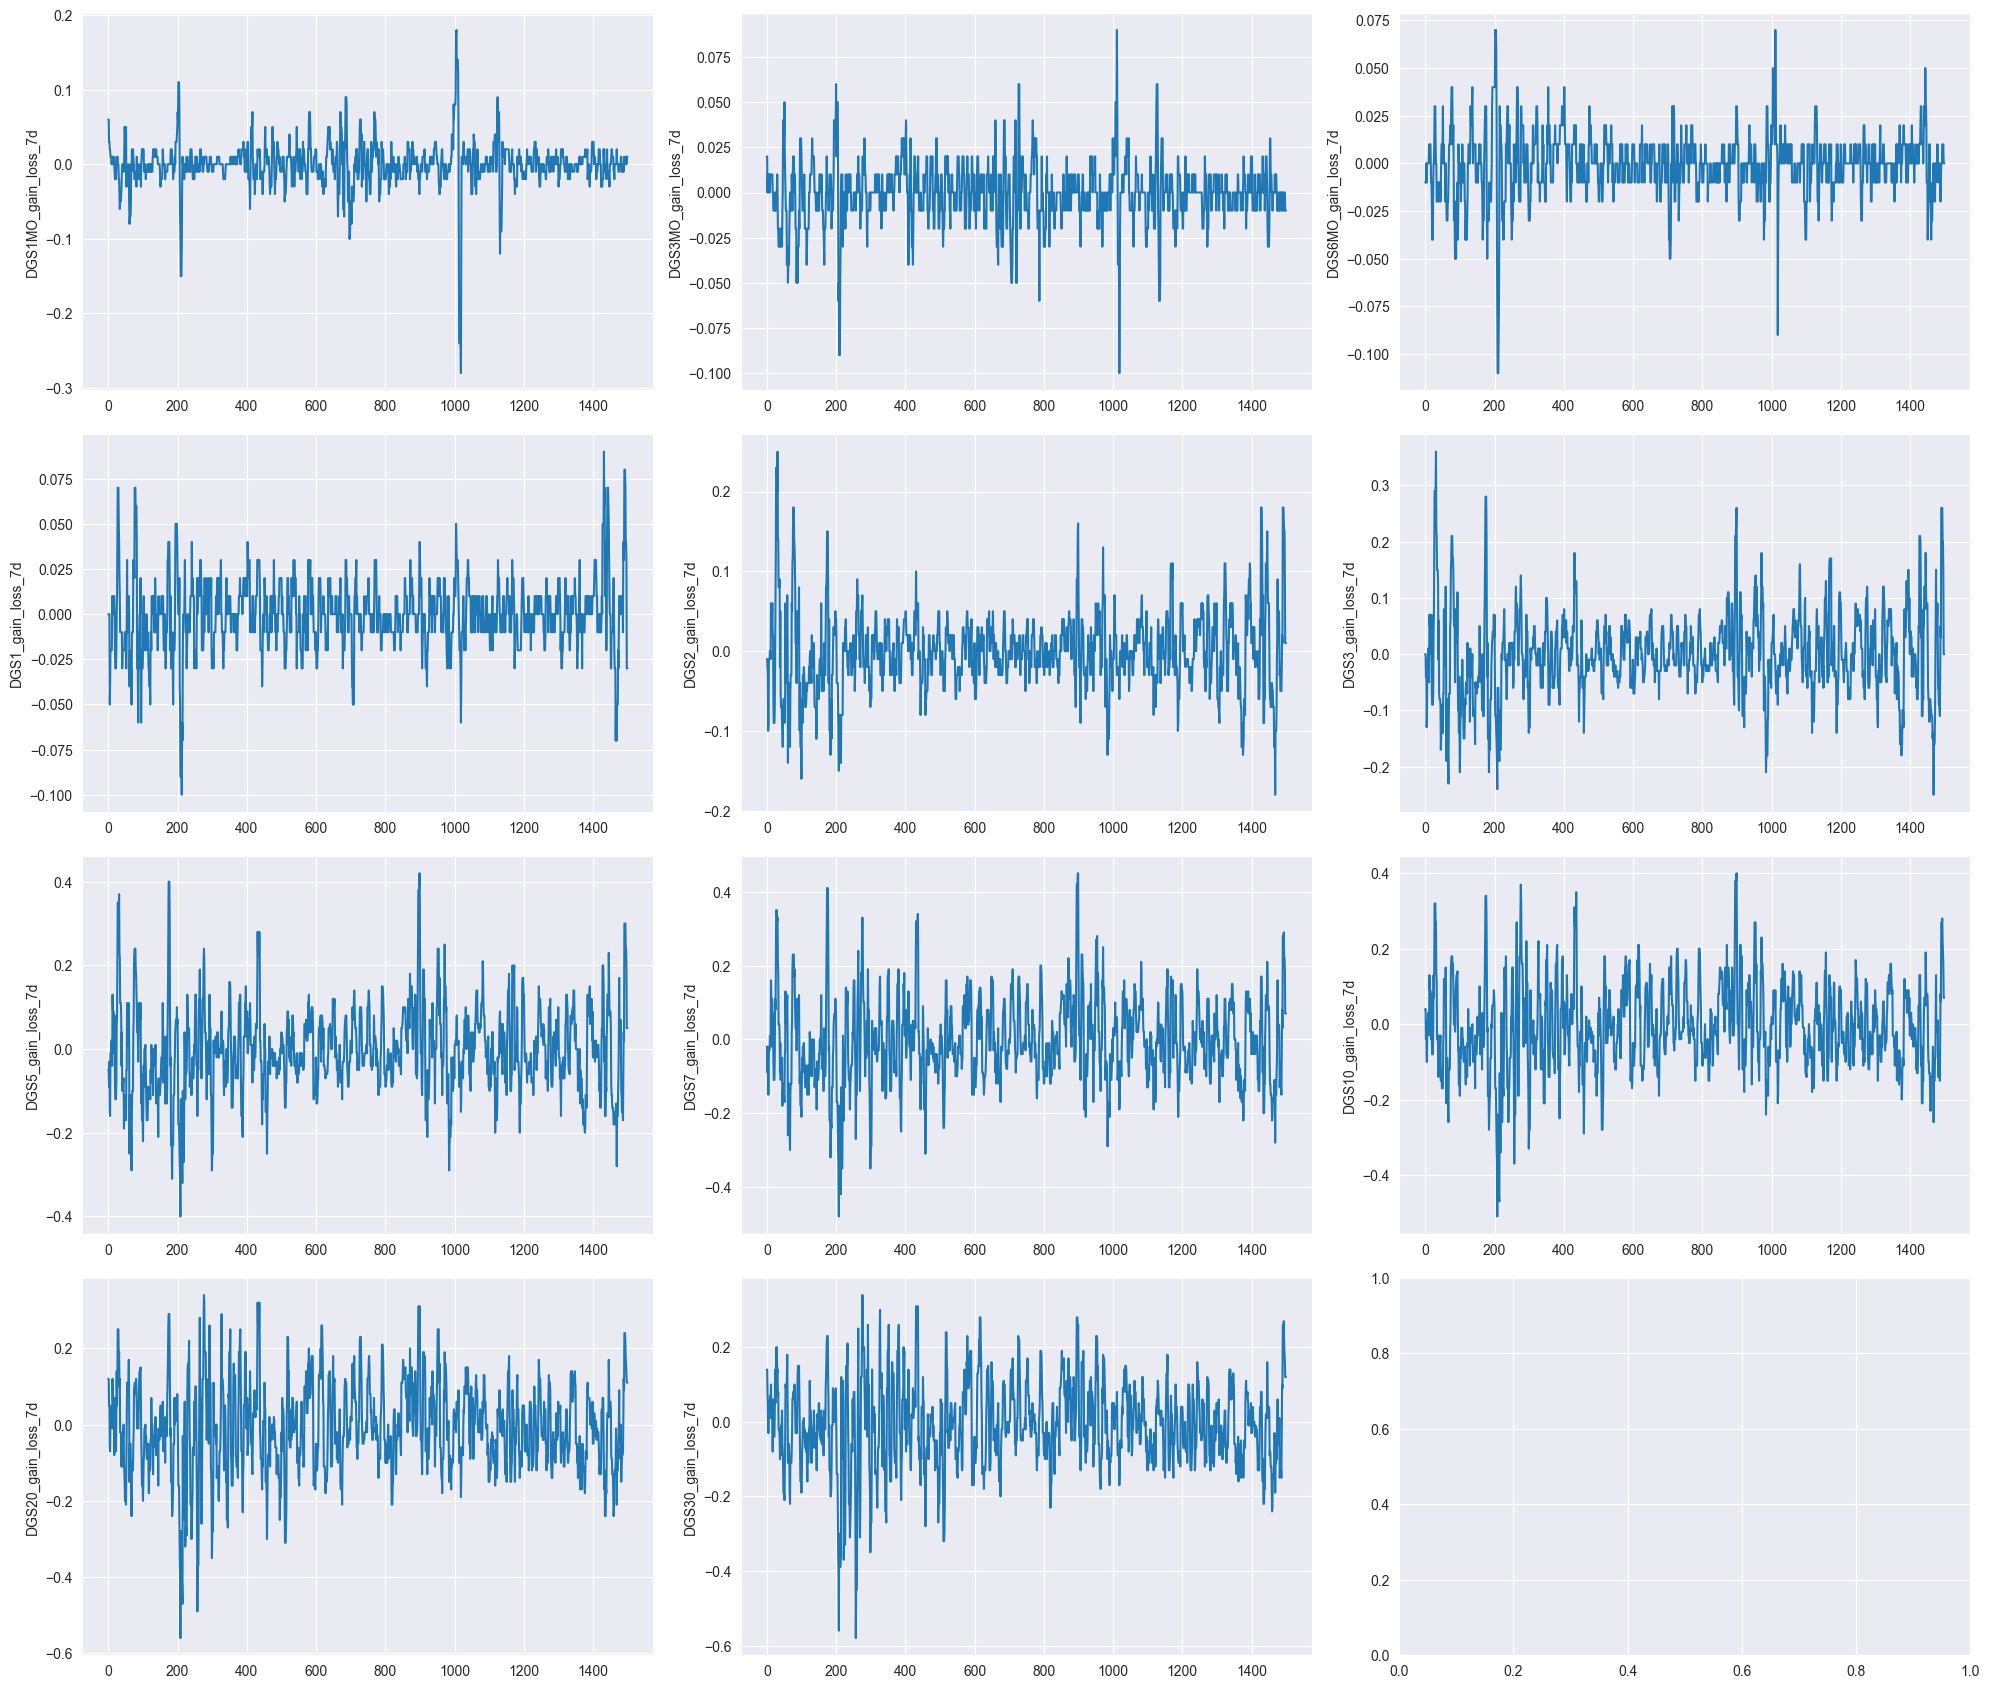

In [87]:
# plot the line graph of the dependent variables
fig, axes = plt.subplots(4, 3, figsize=(20, 17))
axes = axes.flatten()
xlables = [x for x in range(len(analysis_df))]
for i, dependent_var in enumerate(dependent_variables):
    sns.lineplot(analysis_df, x=xlables, y=dependent_var, ax=axes[i])
    ax.set_title(dependent_var)
plt.tight_layout()
plt.show()

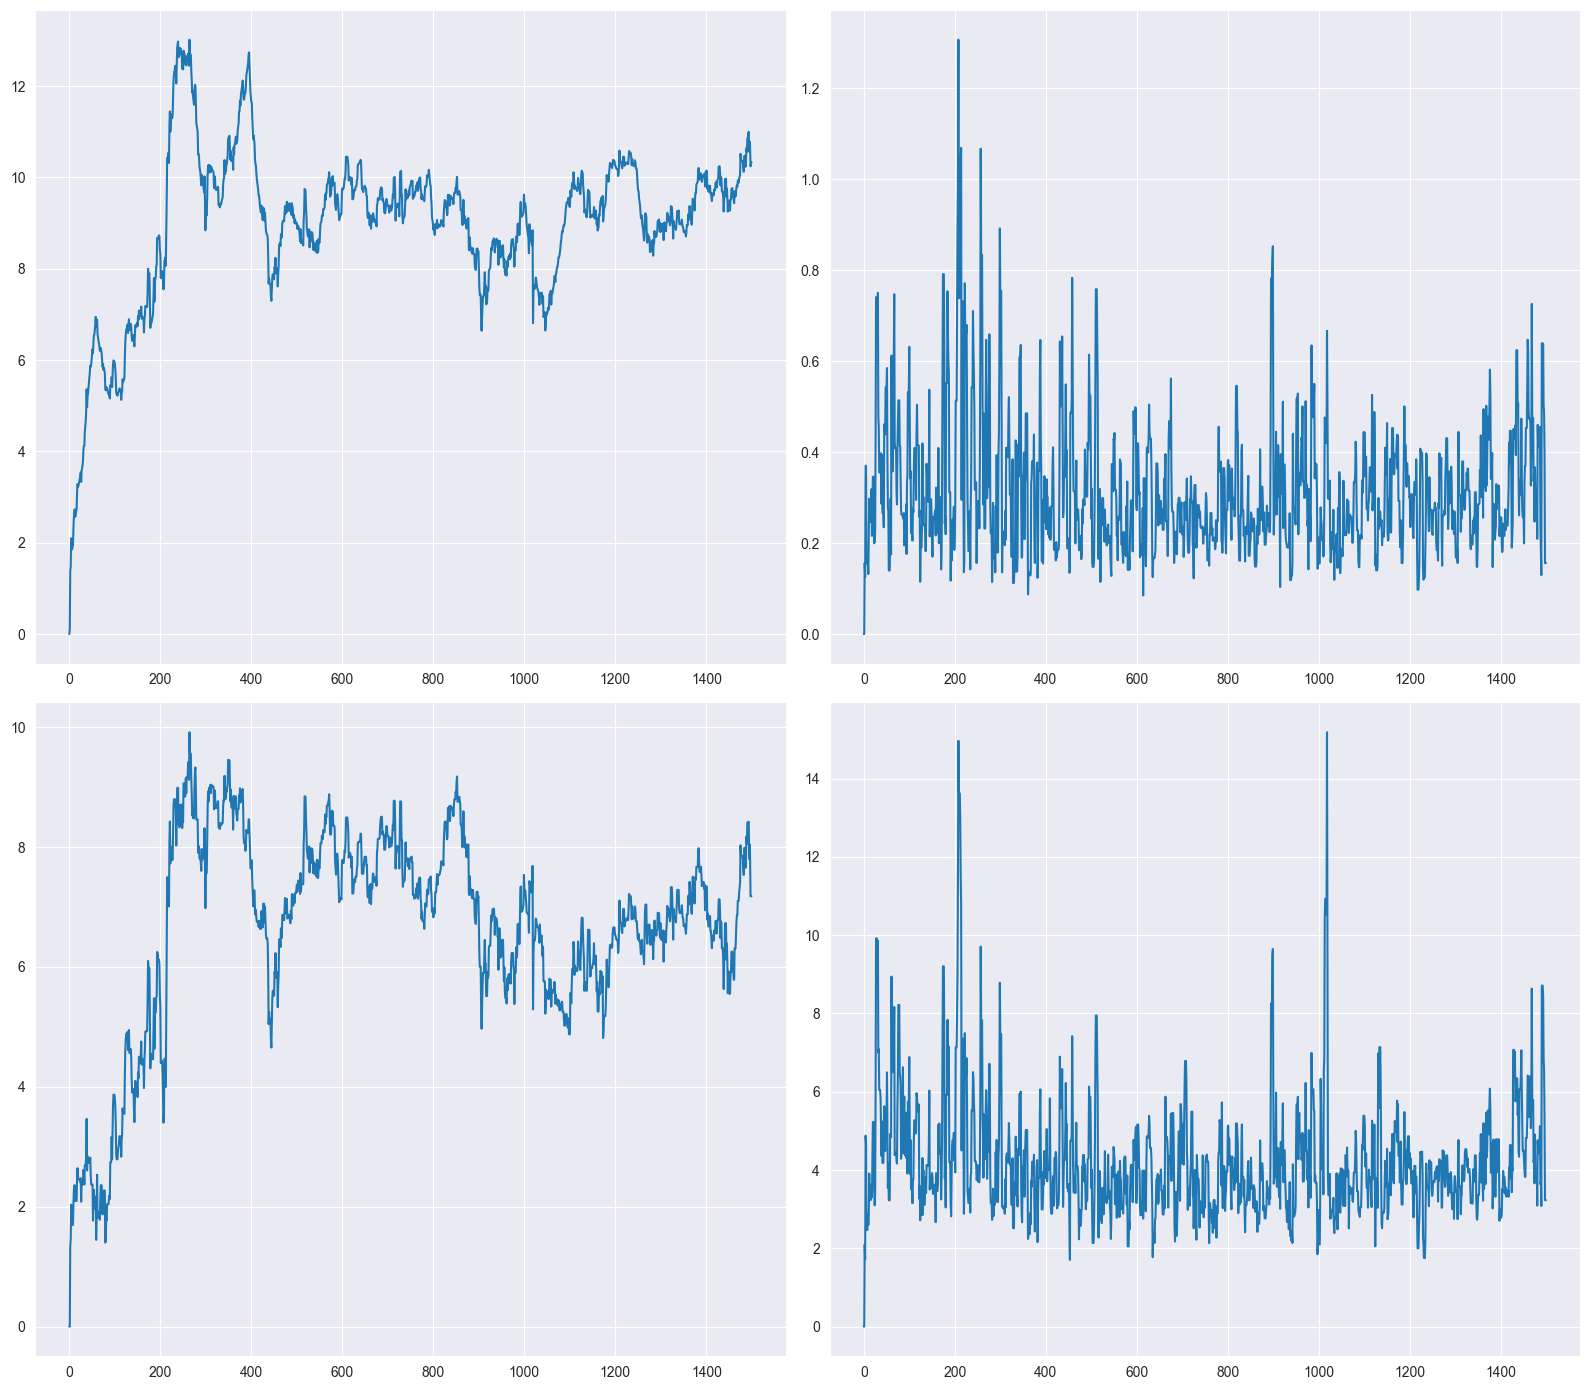

In [207]:
# smooth the values using a 7 day sliding window of the exponential weighted mean with an alpha of 0.5 and plot
# train_df_smooth = analysis_df[dependent_variables].ewm(span=30).mean()
# fig, axes = plt.subplots(4, 3, figsize=(20, 17))
# axes = axes.flatten()
# xlables = [x for x in range(len(analysis_df))]
# for i, dependent_var in enumerate(dependent_variables):
#     sns.lineplot(train_df_smooth, x=xlables, y=dependent_var, ax=axes[i])
#     ax.set_title(dependent_var)
# plt.tight_layout()
# plt.show()

# get the euclidian distance of the features

x_values = analysis_df[independent_variables].values
yvalues = analysis_df[dependent_variables].values
yvalues2 = analysis_df[depenedent_vars2].values
yvalues3 = analysis_df[depenedent_vars3].values

initial_x = x_values[0]
initial_y = yvalues[0]
initial_y2 = yvalues2[0]
initial_y3 = yvalues3[0]
euclidian_valuesx = []
euclidian_valuesy = []
euclidian_valuesy2 = []
euclidian_valuesy3 = []

for vals, yval, yval2, yval3 in zip(x_values, yvalues, yvalues2, yvalues3):
    euclidian_distancex = np.linalg.norm(vals - initial_x)
    euclidian_distancey = np.linalg.norm(yval - initial_y)
    euclidian_distancey2 = np.linalg.norm(yval2 - initial_y2)
    euclidian_distancey3 = np.linalg.norm(yval3 - initial_y3)
    euclidian_valuesx.append(euclidian_distancex)
    euclidian_valuesy.append(euclidian_distancey)
    euclidian_valuesy2.append(euclidian_distancey2)
    euclidian_valuesy3.append(euclidian_distancey3)

# plot the euclidean distance

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()
xlables = [x for x in range(len(euclidian_valuesx))]
for i, euc in enumerate([euclidian_valuesx, euclidian_valuesy, euclidian_valuesy2, euclidian_valuesy3]):
    sns.lineplot(x=xlables, y=euc, ax=axes[i])
    # ax.set_title(dependent_var)
plt.tight_layout()
plt.show()

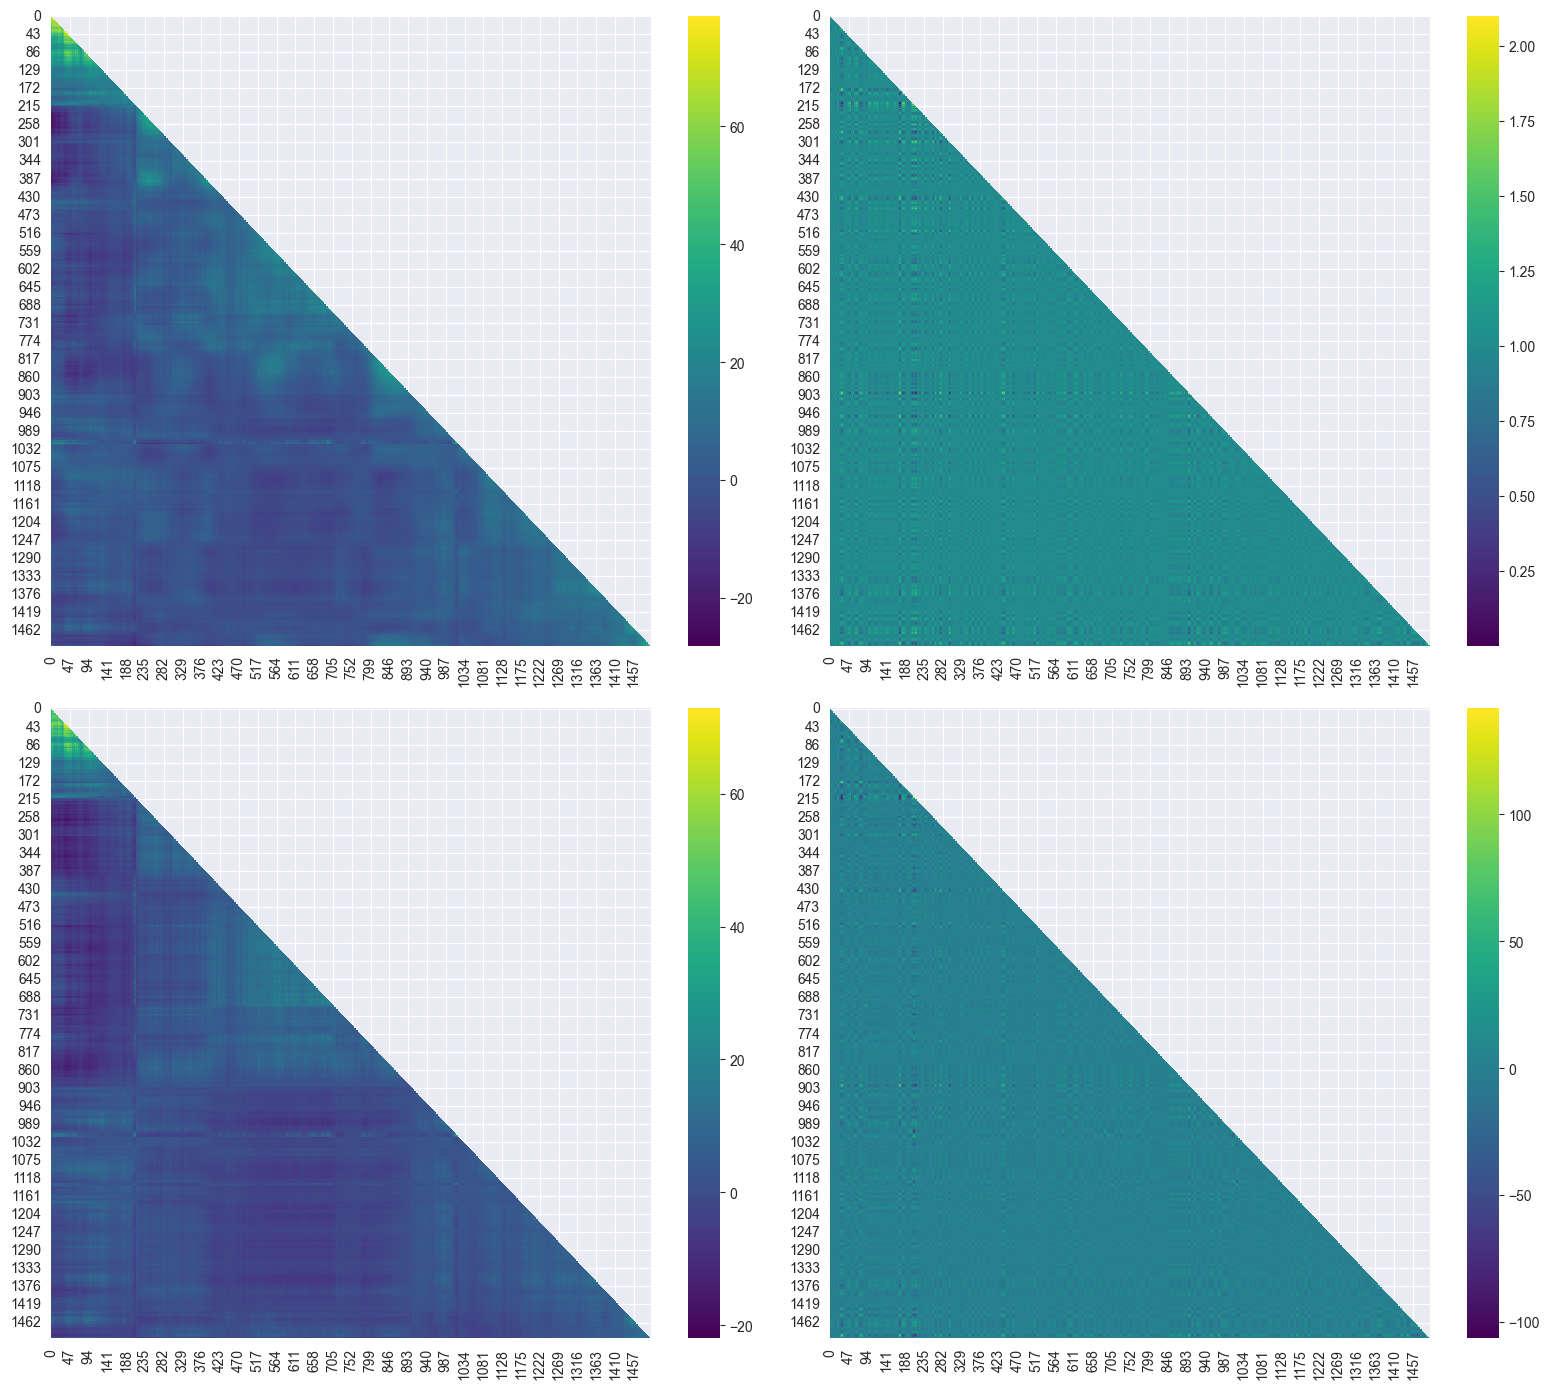

In [282]:
# plot the conditional distribution of a dependent variable along with the independent variables

# dependent_var = depenedent_vars2[5]
# fig, axes = plt.subplots(6, 3, figsize=(25, 22))
# axes = axes.flatten()
# for i, independent_var in enumerate(independent_variables):
#     sns.kdeplot(analysis_df, x=independent_var, y=dependent_var, ax=axes[i])
#     ax.set_title(f"{independent_var} vs {dependent_var}")
# plt.tight_layout()
# plt.show()

kernel_test = (ConstantKernel(1.0, (1e-3, 1e3)) *
                   DotProduct() *
                   RBF(length_scale=1.5, length_scale_bounds=(1e-7, 1e7)) +
                   WhiteKernel(noise_level=1e-5))

kernel_test2 =(ConstantKernel(1.0, (1e-3, 1e3)) *
                                 # DotProduct() *
                                 RationalQuadratic(length_scale=1.0, alpha=0.1,
                                                 length_scale_bounds=(1e-6, 1e6),
                                                 alpha_bounds=(1e-5, 1e5)) +
                                 WhiteKernel(noise_level=1e-5))

kernel_test3 = (ConstantKernel(1.0, (1e-3, 1e3)) *
                              DotProduct() *
                              ExpSineSquared(length_scale=2, periodicity=20.0,
                                           length_scale_bounds=(0.01, 10),
                                           periodicity_bounds=(1e-2, 1e2)) +
                              WhiteKernel(noise_level=1e-5))

x_values = analysis_df[independent_variables].to_numpy()
yvalues = analysis_df[dependent_variables].to_numpy()
yvalues2 = analysis_df[depenedent_vars2].to_numpy()
yvalues3 = analysis_df[depenedent_vars3].to_numpy()

x_cov = kernel_test3(x_values, x_values)
y_cov = kernel_test3(yvalues, yvalues)
y_cov2 = kernel_test3(yvalues2, yvalues2)
y_cov3 = kernel_test3(yvalues3, yvalues3)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for i, cov_mat in enumerate([x_cov, y_cov, y_cov2, y_cov3]):
    sns.heatmap(cov_mat, cmap='viridis', mask=np.triu(np.ones_like(x_cov, dtype=bool)), cbar=True, ax=axes[i])
    # ax.set_title(f"Covariance Matrix for {depenedent_vars3[i]}")
plt.tight_layout()
plt.show()

## kernel analysis


In [197]:
kernel = (ConstantKernel(1.0, (1e-3, 1e3)) *
                                 Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5) +
                                 WhiteKernel(noise_level=1e-5))


kernel2 = (ConstantKernel(1.0, (1e-3, 1e3)) *
                              Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5) * DotProduct() + WhiteKernel(noise_level=1e-5))

In [283]:
# create the GPR model
gpr_model_1 = GaussianProcessRegressor(kernel=kernel_test2, alpha=0.01, normalize_y=False, n_restarts_optimizer=3)

gpr_model_2 = GaussianProcessRegressor(kernel=kernel_test3, alpha=0.0, normalize_y=False, n_restarts_optimizer=3)

gpr_model_3 = GaussianProcessRegressor(kernel=kernel_test3, alpha=0.1, normalize_y=False, n_restarts_optimizer=3)

In [284]:
# train the models on the data
xtrain = analysis_df[independent_variables]
ytrain = analysis_df[dependent_variables]
ytrain2  = analysis_df[depenedent_vars2]
ytrain3 = analysis_df[depenedent_vars3]

# train the models in
models = [gpr_model_1, gpr_model_2, gpr_model_3]
ytrain_list = [ytrain, ytrain2, ytrain3]

trained_models = []
for model, y_data in tqdm(zip(models, ytrain_list), desc='Model training: ', total=len(models)):
    model = MultiOutputRegressor(model, n_jobs=2)
    model.fit(xtrain, y_data)
    trained_models.append(model)

gpr_model_1 = trained_models[0]
gpr_model_2 = trained_models[1]
gpr_model_3 = trained_models[2]
print("Completed training the models")
# get the predictions and store as a dataframe and transform back to its original form
y_pred = gpr_model_1.predict(xtrain)
# y_pred, y_cov = gpr_model_1.predict(xtrain)

y_pred2 = gpr_model_2.predict(xtrain)
# y_pred2, y_cov2 = gpr_model_2.predict(xtrain)

y_pred3 = gpr_model_3.predict(xtrain)
# y_pred3, y_cov3 = gpr_model_3.predict(xtrain)

# convert to a dataframes and back to its original form

df_predictions = pd.DataFrame(y_pred, columns=dependent_variables)
df_predictions2 = pd.DataFrame(y_pred2, columns=depenedent_vars2)
df_predictions3 = pd.DataFrame(y_pred3, columns=depenedent_vars3)

# df_predictions = scaler.inverse_transform(df_predictions)
df_predictions2 = scaler2.inverse_transform(df_predictions2)
df_predictions3 = scaler3.inverse_transform(df_predictions3)

df_predictions2 = pd.DataFrame(y_pred2, columns=depenedent_vars2, index=analysis_df.index)
df_predictions3 = pd.DataFrame(y_pred3, columns=depenedent_vars3, index=analysis_df.index)
df_predictions.index = analysis_df.index

print("Full training pipeline completed.")
df_predictions3.head()

Model training:  33%|███▎      | 1/3 [03:37<07:15, 217.86s/it]


LinAlgError: ("The kernel, 1**2 * DotProduct(sigma_0=1) * ExpSineSquared(length_scale=2, periodicity=20) + WhiteKernel(noise_level=1e-05), is not returning a positive definite matrix. Try gradually increasing the 'alpha' parameter of your GaussianProcessRegressor estimator.", '260-th leading minor of the array is not positive definite')

In [268]:
ytrain3_original = scaler3.inverse_transform(analysis_df[depenedent_vars3])
df_ytrain3 = pd.DataFrame(ytrain3_original, columns=depenedent_vars3, index=analysis_df.index)

ytrain2_original = scaler2.inverse_transform(analysis_df[depenedent_vars2])
df_ytrain2 = pd.DataFrame(ytrain2_original, columns=depenedent_vars2, index=analysis_df.index)

df_ytrain2.describe()

,DGS1MO_actuals_forecasting,DGS3MO_actuals_forecasting,DGS6MO_actuals_forecasting,DGS1_actuals_forecasting,DGS2_actuals_forecasting,DGS3_actuals_forecasting,DGS5_actuals_forecasting,DGS7_actuals_forecasting,DGS10_actuals_forecasting,DGS20_actuals_forecasting,DGS30_actuals_forecasting
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,0.044700,0.055973,0.094507,0.153027,0.377820,0.648593,1.275260,1.810427,2.354907,3.063267,3.377920
std,0.039015,0.035657,0.040071,0.049251,0.145733,0.281605,0.465494,0.533324,0.538352,0.582641,0.549389
min,0.000000,0.000000,0.020000,0.080000,0.160000,0.280000,0.560000,0.910000,1.430000,2.040000,2.250000
25%,0.020000,0.030000,0.060000,0.110000,0.270000,0.390000,0.830000,1.340000,1.920000,2.630000,2.980000
50%,0.030000,0.050000,0.090000,0.140000,0.330000,0.610000,1.360000,1.910000,2.290000,2.940000,3.235000
75%,0.060000,0.080000,0.130000,0.180000,0.450000,0.890000,1.650000,2.200000,2.720000,3.410000,3.692500
max,0.320000,0.160000,0.190000,0.310000,0.870000,1.410000,2.400000,3.120000,3.750000,4.560000,4.760000


In [269]:
# get the residuals between the actuals and predictions
residuals_df = df_predictions - analysis_df[dependent_variables]
residuals_df2 = df_predictions2 - df_ytrain2
residuals_df3 = df_predictions3 - df_ytrain3
# captured residuals
print("Captured residuals")

Captured residuals


In [270]:
df_predictions2.tail()

,DGS1MO_actuals_forecasting,DGS3MO_actuals_forecasting,DGS6MO_actuals_forecasting,DGS1_actuals_forecasting,DGS2_actuals_forecasting,DGS3_actuals_forecasting,DGS5_actuals_forecasting,DGS7_actuals_forecasting,DGS10_actuals_forecasting,DGS20_actuals_forecasting,DGS30_actuals_forecasting
period,,,,,,,,,,,
2015-02-04,-0.838159,-1.204378,-0.828685,0.970707,0.987980,0.755620,0.030249,-0.384209,-1.028297,-1.541525,-1.817955
2015-02-05,-0.673824,-1.048837,-0.812530,0.992165,0.999136,0.778432,0.053992,-0.357884,-0.990094,-1.493624,-1.761740
2015-02-06,-0.882361,-1.007434,-0.602685,2.150240,1.848596,1.338417,0.432909,-0.074921,-0.745442,-1.336415,-1.570034
2015-02-07,-0.880712,-1.000812,-0.608450,2.144683,1.835990,1.324550,0.426009,-0.076223,-0.739090,-1.321257,-1.554646
2015-02-08,-0.874205,-0.988431,-0.610119,2.126623,1.814253,1.304271,0.417582,-0.076558,-0.728136,-1.298925,-1.530611


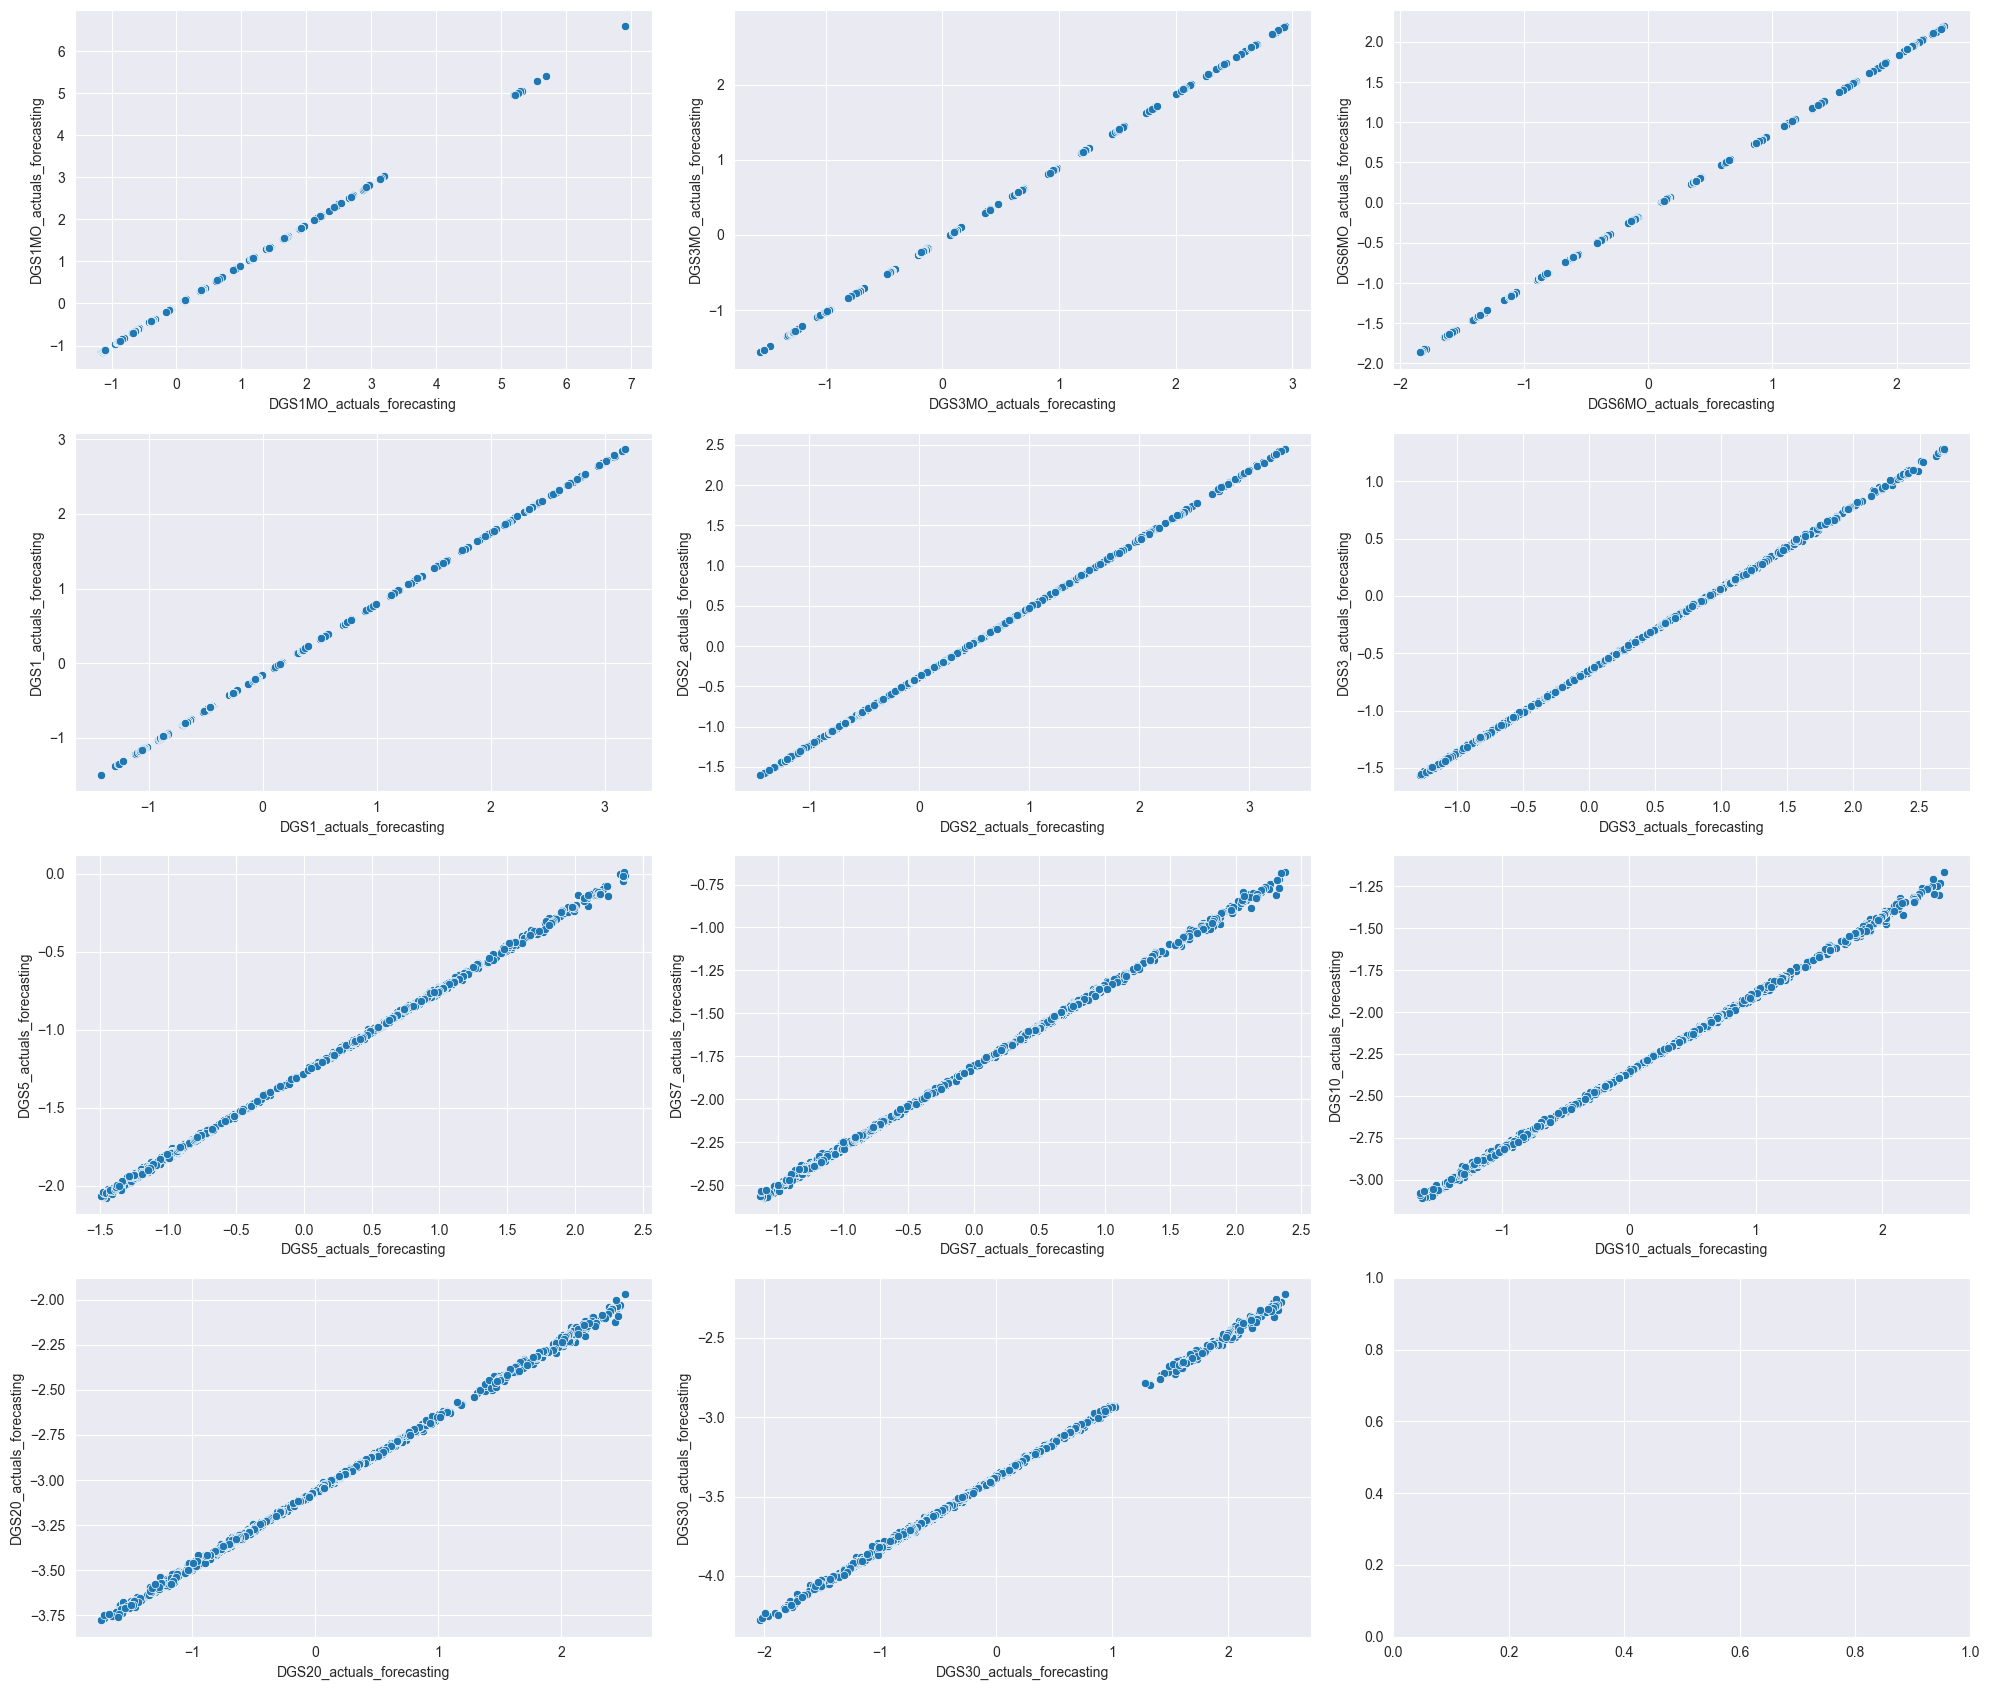

In [272]:
# plot the residuals
# prediction_plot = df_predictions
# actuals_plot = analysis_df[dependent_variables]
# resid_plot = residuals_df

# prediction_plot = df_predictions3
# actuals_plot = df_ytrain3
# resid_plot = residuals_df3

prediction_plot = df_predictions2
actuals_plot = df_ytrain2
resid_plot = residuals_df2

fig, axes = plt.subplots(4, 3, figsize=(20, 17))
axes = axes.flatten()
for i, depend_var in enumerate(prediction_plot.columns.tolist()):
    sns.scatterplot(x=prediction_plot[depend_var], y=resid_plot[depend_var], ax=axes[i])
    ax.set_title(depend_var)
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Covariance Matrix for DGS3_gain_loss_7d_normalized')

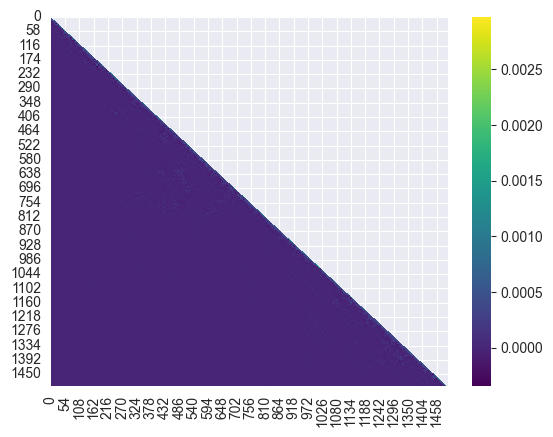

In [236]:
# k = 0 # choose which of the 11 dependent variables
# fig, axes = plt.subplots(4, 3, figsize=(20, 17))
# axes = axes.flatten()
# for i in range(11):
#     cov_mat = y_cov3[:, :, i]
#     sns.heatmap(cov_mat, cmap='viridis', mask=np.triu(np.ones_like(cov_mat, dtype=bool)), cbar=True, ax=axes[i])
#     ax.set_title(f"Covariance Matrix for {depenedent_vars3[i]}")
# plt.tight_layout()
# plt.show()
i = 5
cov_mat = y_cov2[:, :, i]
sns.heatmap(cov_mat, cmap='viridis', mask=np.triu(np.ones_like(cov_mat, dtype=bool)), cbar=True)
ax.set_title(f"Covariance Matrix for {depenedent_vars3[i]}")


<Axes: >

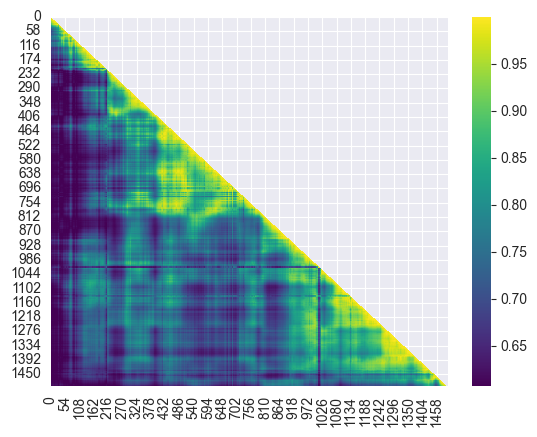

In [237]:
x_cov = gpr_model_2.kernel(xtrain, xtrain)
sns.heatmap(x_cov, cmap='viridis', mask=np.triu(np.ones_like(x_cov, dtype=bool)), cbar=True)

In [192]:
# predict the out of sample data
validation_set = train_df.iloc[1500:]
x_validation = scaler.transform(validation_set[independent_variables])
y_validation = validation_set[dependent_variables]
y_validation.columns = depenedent_vars2

validation_predctions = gpr_model_2.predict(x_validation, return_std=False)
df_validation_predctions = pd.DataFrame(validation_predctions, columns=dependent_variables, index=validation_set.index)
df_validation_predctions = scaler2.inverse_transform(df_validation_predctions)
df_validation_predctions = pd.DataFrame(validation_predctions, columns=depenedent_vars2, index=validation_set.index)
print(f"Predicted validation set: {df_validation_predctions.shape}")

Predicted validation set: (1057, 11)


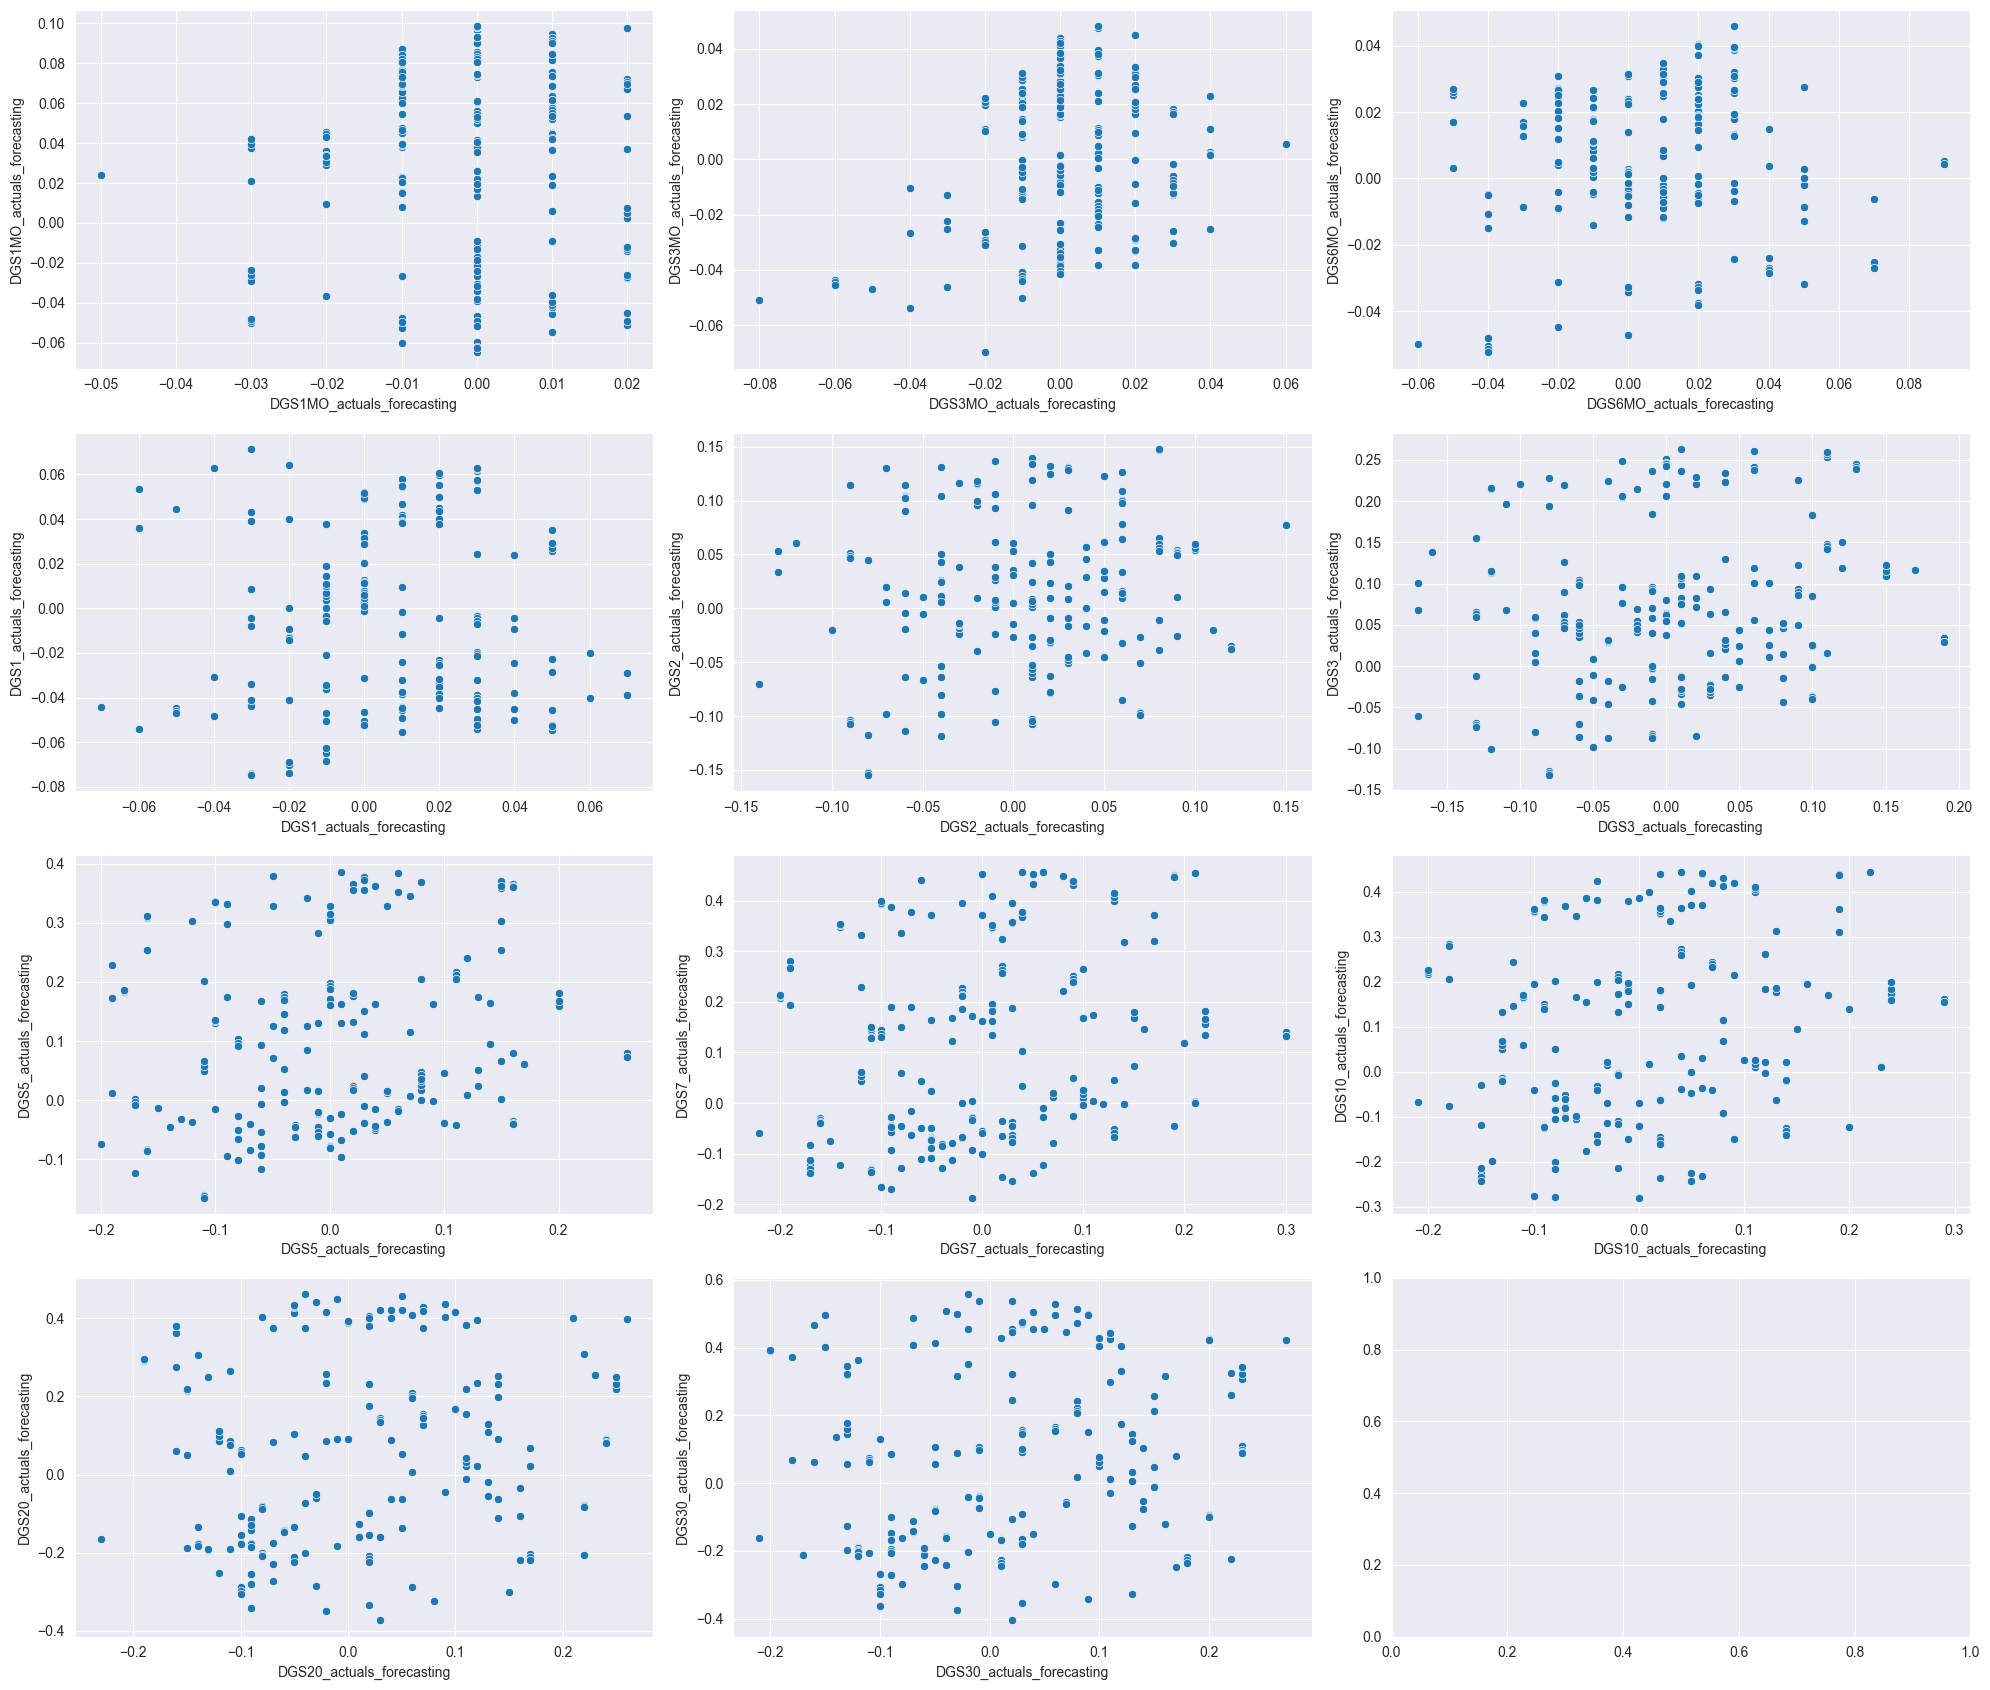

In [194]:
# get the residuals and plot
# residuals_validation = df_validation_predctions - y_validation
head_val = 200
fig, axes = plt.subplots(4, 3, figsize=(20, 17))
axes = axes.flatten()
for i, depend_var in enumerate(residuals_validation.columns.tolist()):
    sns.scatterplot(x=y_validation[depend_var].head(head_val), y=df_validation_predctions[depend_var].head(head_val), ax=axes[i])
    ax.set_title(depend_var)
plt.tight_layout()
plt.show()

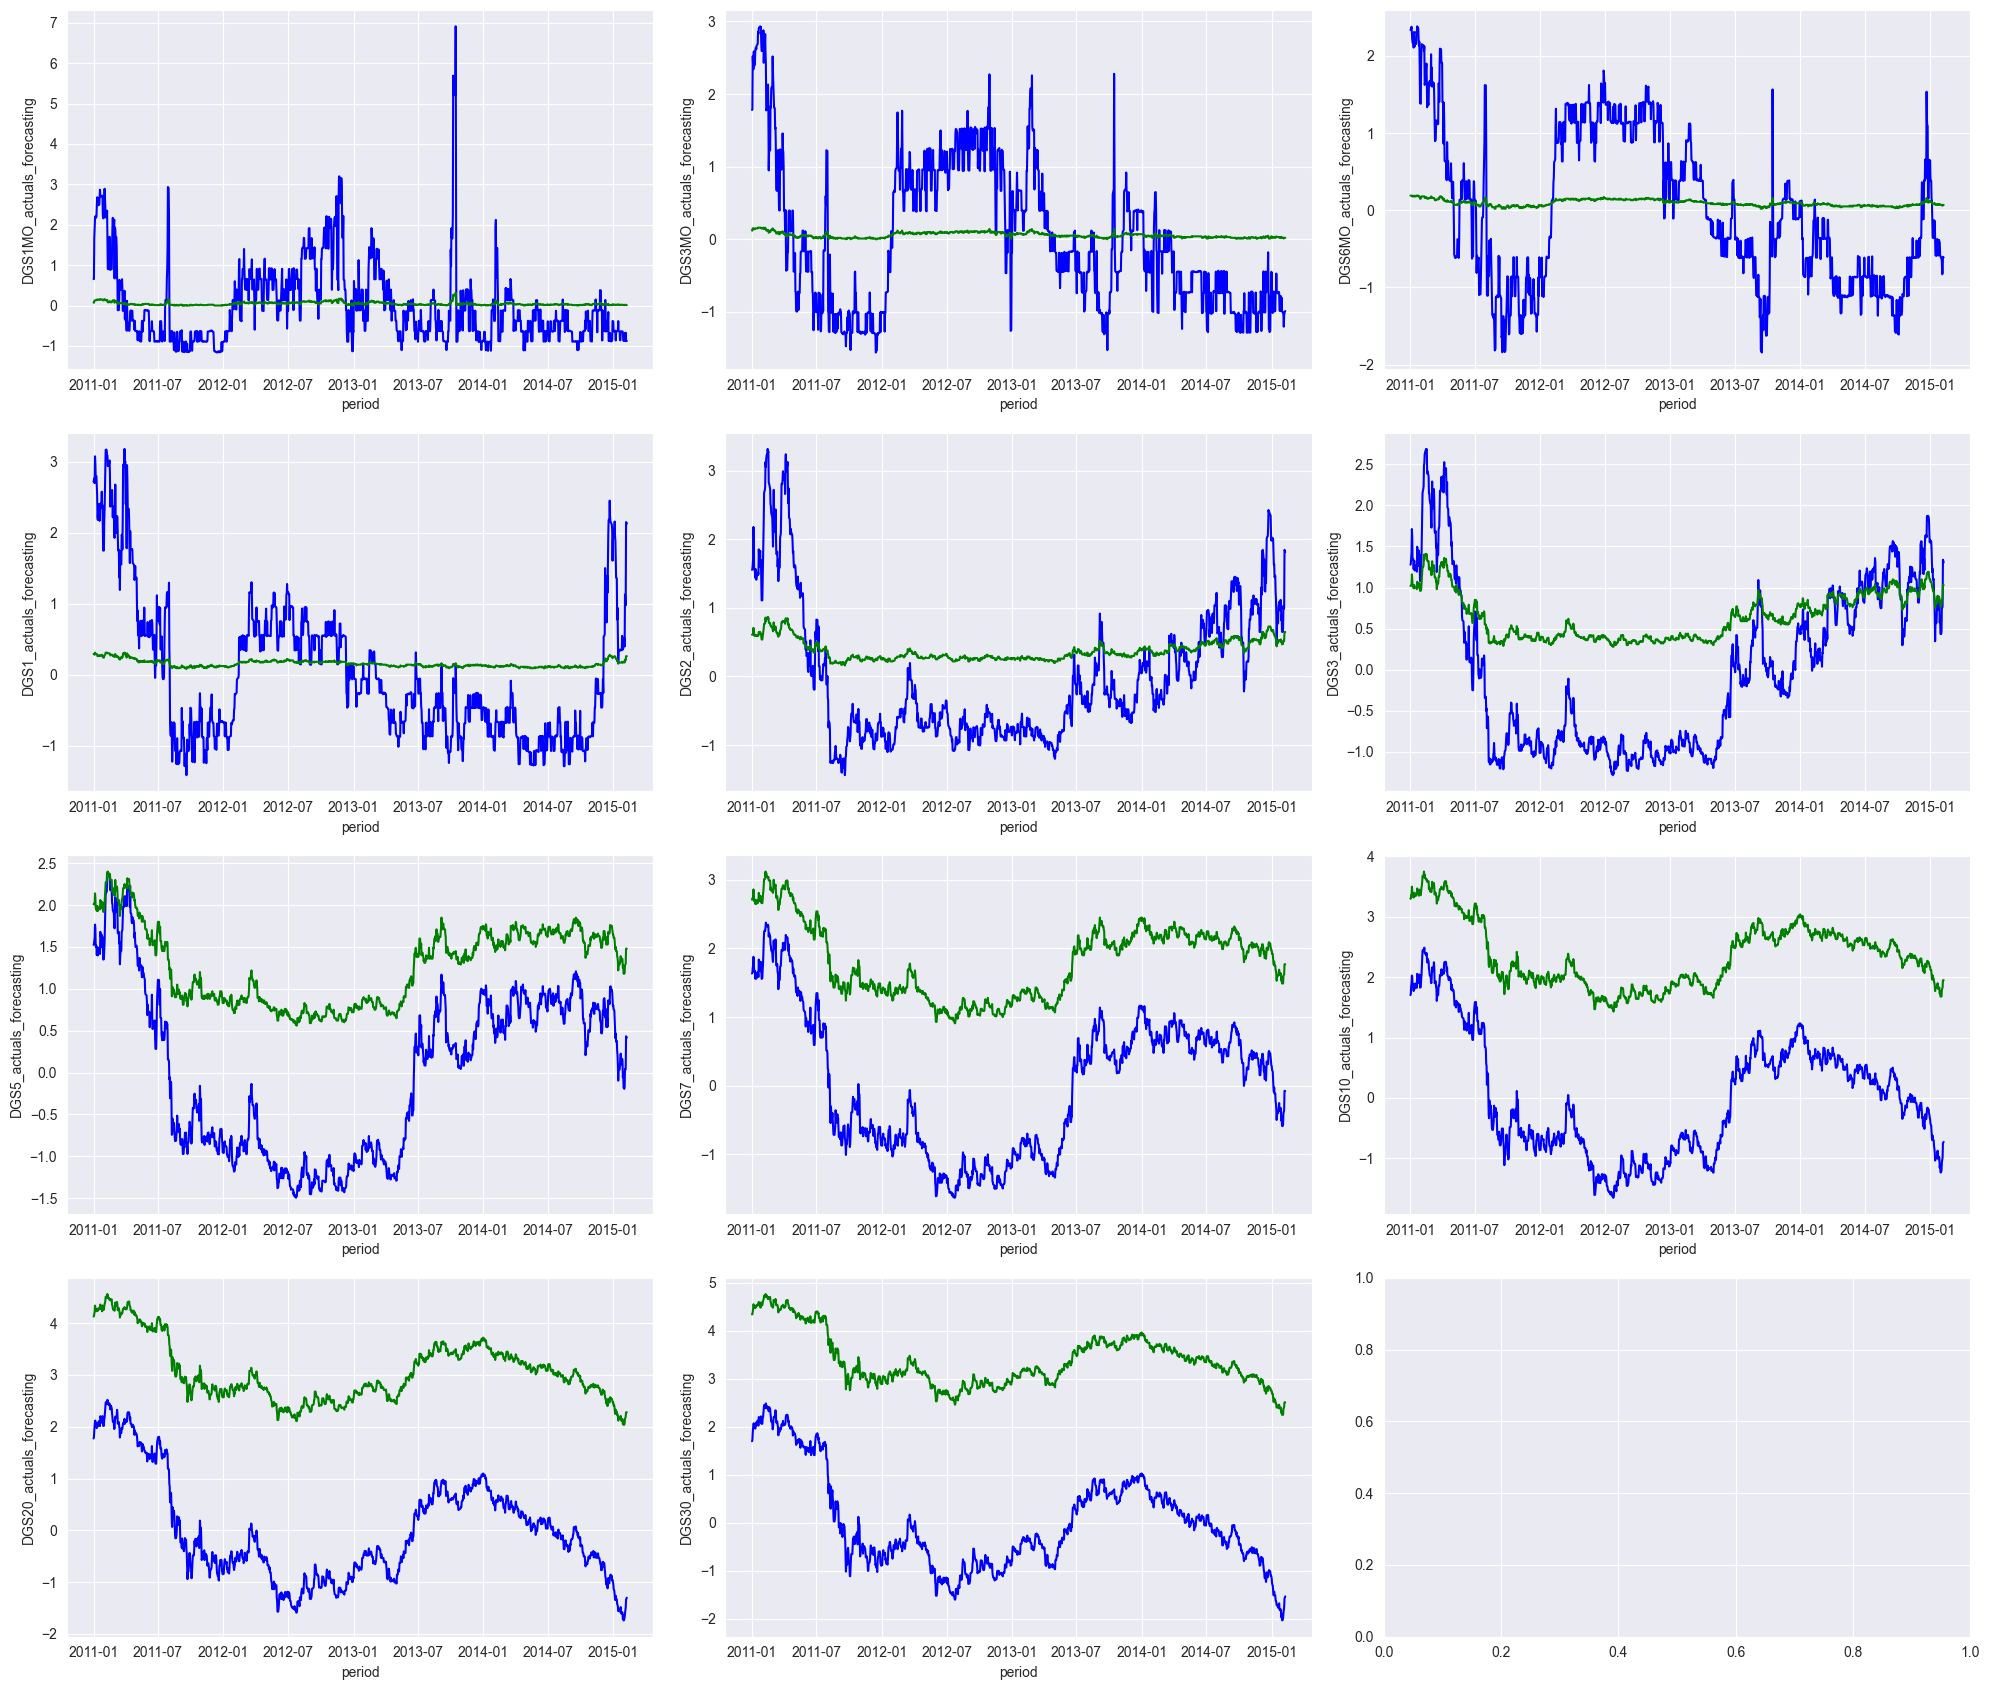

In [273]:
# plot the training data
fig, axes = plt.subplots(4, 3, figsize=(20, 17))
axes = axes.flatten()
# df_predictions2
# df_ytrain2
for i, depend_var in enumerate(df_predictions2.columns.tolist()):
    xlabs = df_predictions2.index.to_timestamp()
    sns.lineplot(x=xlabs, y=df_predictions2[depend_var], color= 'b', ax=axes[i])
    sns.lineplot(x=xlabs, y=df_ytrain2[depend_var], color= 'g', ax=axes[i])
    ax.set_title(depend_var)
plt.tight_layout()
plt.show()

## GPR Analysis